# 01 - Diabetes Risk Prediction (Tabular Data)

**Dataset:** [Diabetes Risk Prediction Dataset (50K Patients)](https://www.kaggle.com/datasets/mobeenfatimah/diabetes-risk-prediction-dataset-50k-patients)

So sánh 3 kiến trúc CNN **độc lập với nhau**, đều lấy từ `torchvision.models` (không tự xây dựng kiến trúc từ đầu):

1. **ResNet18**
2. **MobileNetV3-Small**
3. **ShuffleNetV2 (x1.0)**

MobileNetV3-Small và ShuffleNetV2 được chọn vì đây là 2 kiến trúc CNN nhẹ (ít tham số, nhiều depthwise/group convolution), phù hợp với dữ liệu bảng đã được "ảnh hoá" (kích thước nhỏ, không có nhiều chi tiết không gian phức tạp như ảnh tự nhiên) — giúp tránh overfitting so với các mạng rất sâu.

Vì `torchvision.models` chỉ nhận đầu vào dạng ảnh 2D 3 kênh, mỗi vector đặc trưng (feature vector) của một bệnh nhân sẽ được "ảnh hoá" (reshape thành ảnh vuông nhỏ, resize lên kích thước cố định, nhân bản thành 3 kênh) trước khi đưa vào mô hình. Cả 3 mô hình huấn luyện **độc lập** trên cùng tập train/val/test rồi so sánh hiệu năng.

In [1]:
# ============================================================
# COMMON SETUP
# ============================================================
import os, random, time, json, copy, math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
print("torchvision:", torchvision.__version__)

DEVICE: cuda
torchvision: 0.29.0+cu126


## 1. Cấu hình đường dẫn & load dữ liệu

In [2]:
# =========================
# 1. CAU HINH DUONG DAN
# =========================
# Neu chay Kaggle:
DATA_PATH = r"D:\Dai hoc\Phat trien cac he thong thong minh\Assignment 05\diabetes\data\diabetes_risk_prediction_dataset.csv"

# Neu chay may ca nhan, sua thanh duong dan CSV cua ban:
# DATA_PATH = r"D:\...\diabetes_risk_prediction_dataset.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

Shape: (50000, 41)


,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,Yes,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,Yes,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High



Columns:
['Patient_ID', 'Age', 'Gender', 'Country', 'Height_cm', 'Weight_kg', 'BMI', 'Waist_Circumference_cm', 'Blood_Glucose', 'HbA1c', 'Fasting_Blood_Sugar', 'Insulin_Level', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'Total_Cholesterol', 'HDL', 'LDL', 'Triglycerides', 'Heart_Rate', 'Physical_Activity_Level', 'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Diet_Quality', 'Sugar_Intake_Level', 'Sleep_Hours', 'Stress_Level', 'Smoking_Status', 'Alcohol_Consumption', 'Family_History_Diabetes', 'Hypertension', 'Heart_Disease', 'Fatty_Liver', 'PCOS', 'Medication_Adherence', 'Work_Type', 'Residence_Type', 'Daily_Water_Intake_L', 'Diabetes_Risk_Score', 'AI_Health_Recommendation', 'Doctor_Consultation_Needed', 'Diabetes_Risk']


## 2. Xác định target + khảo sát

In [3]:
# =========================
# 2. XAC DINH TARGET + KHAO SAT
# =========================
TARGET = "Diabetes_Risk"

print(df[TARGET].value_counts(dropna=False))
print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).head(15))

# Loai ID va cac cot text/risk recommendation co kha nang khong phu hop
drop_cols = [c for c in ["Patient_ID"] if c in df.columns]

# Loai cac cot sinh ra tu target/risk hoac khuyen nghi neu co.
# Ban nen kiem tra ten cot thuc te truoc khi chay.
leak_keywords = [
    "risk_score", "risk score", "recommendation", "doctor",
    "diagnosis", "status"
]
for c in df.columns:
    if c == TARGET:
        continue
    if any(k in c.lower() for k in leak_keywords):
        drop_cols.append(c)

drop_cols = sorted(set(drop_cols))
print("Drop:", drop_cols)

Diabetes_Risk
High        36593
Moderate    12937
Low           470
Name: count, dtype: int64

Missing values:


Weight_kg                  2962
Height_cm                  2945
Sleep_Hours                2017
Exercise_Hours_Per_Week    1992
HbA1c                      1974
Daily_Walking_Minutes      1964
HDL                        1000
LDL                        1000
Triglycerides              1000
Medication_Adherence       1000
Total_Cholesterol          1000
Blood_Glucose               959
Physical_Activity_Level     500
Age                         497
Patient_ID                    0
dtype: int64

Drop: ['AI_Health_Recommendation', 'Diabetes_Risk_Score', 'Doctor_Consultation_Needed', 'Patient_ID', 'Smoking_Status']


## 3. Tiền xử lý dữ liệu dạng bảng

In [4]:
# =========================
# 3. PREPROCESS TABULAR DATA
# =========================
work = df.drop(columns=drop_cols, errors="ignore").copy()

# Target ve 0/1.
y_raw = work[TARGET]
if pd.api.types.is_numeric_dtype(y_raw):
    y = y_raw.astype(int).to_numpy()
else:
    classes_ = sorted(y_raw.dropna().astype(str).unique())
    print("Target classes:", classes_)
    mapping = {v: i for i, v in enumerate(classes_)}
    y = y_raw.astype(str).map(mapping).to_numpy()

X = work.drop(columns=[TARGET])

# Numeric -> median
num_cols = X.select_dtypes(include=np.number).columns
X_num = X[num_cols].copy()
X_num = X_num.replace([np.inf, -np.inf], np.nan)
X_num = X_num.fillna(X_num.median())

# Categorical -> one-hot
cat_cols = X.select_dtypes(exclude=np.number).columns
X_cat = pd.get_dummies(X[cat_cols].fillna("Unknown"), drop_first=False)

X_all = pd.concat([X_num, X_cat], axis=1).astype(np.float32)

# Chuan hoa tung feature
mean_ = X_all.mean()
std_ = X_all.std().replace(0, 1)
X_all = (X_all - mean_) / std_

X_np = X_all.to_numpy(dtype=np.float32)
N_CLASSES = len(np.unique(y))

print("Processed X:", X_np.shape)
print("y:", y.shape, "classes:", np.unique(y))

Target classes: ['High', 'Low', 'Moderate']
Processed X: (50000, 85)
y: (50000,) classes: [0 1 2]


## 4. Stratified split 70/15/15

In [5]:
# =========================
# 4. STRATIFIED SPLIT 70/15/15
# =========================
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_np, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (35000, 85) Val: (7500, 85) Test: (7500, 85)


## 5. "Ảnh hoá" dữ liệu bảng để dùng với `torchvision.models`

Mỗi dòng dữ liệu (feature vector độ dài `F`) được:
1. Đệm thêm số 0 (zero-pad) cho đủ một hình vuông `side x side` (`side = ceil(sqrt(F))`).
2. Reshape thành ảnh xám 1 kênh `(1, side, side)`.
3. Resize (nội suy song tuyến tính) lên kích thước cố định `64 x 64` để tương thích với các kiến trúc CNN 2D tiêu chuẩn.
4. Nhân bản thành 3 kênh `(3, 64, 64)` để đưa vào `torchvision.models` (vốn được thiết kế cho ảnh RGB).

In [6]:
IMG_TARGET_SIZE = 64
N_FEATURES = X_np.shape[1]
SIDE = math.ceil(math.sqrt(N_FEATURES))
PAD_LEN = SIDE * SIDE - N_FEATURES
print(f"N_FEATURES={N_FEATURES} -> SIDE={SIDE} (pad {PAD_LEN} zeros) -> resize to {IMG_TARGET_SIZE}x{IMG_TARGET_SIZE}x3")


class TabularImageDataset(Dataset):
    """Bien moi dong du lieu bang thanh mot 'anh' 3 kenh de dua vao CNN 2D."""
    def __init__(self, X, y, side, pad_len, target_size):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)
        self.side = side
        self.pad_len = pad_len
        self.target_size = target_size

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        row = self.X[idx]
        if self.pad_len > 0:
            row = np.concatenate([row, np.zeros(self.pad_len, dtype=np.float32)])
        img = torch.tensor(row).reshape(1, self.side, self.side).unsqueeze(0)  # (1,1,side,side)
        img = F.interpolate(img, size=(self.target_size, self.target_size),
                             mode="bilinear", align_corners=False).squeeze(0)   # (1,64,64)
        img = img.repeat(3, 1, 1)  # (3,64,64)
        return img, self.y[idx]


BATCH_SIZE = 128
train_ds = TabularImageDataset(X_train, y_train, SIDE, PAD_LEN, IMG_TARGET_SIZE)
val_ds   = TabularImageDataset(X_val,   y_val,   SIDE, PAD_LEN, IMG_TARGET_SIZE)
test_ds  = TabularImageDataset(X_test,  y_test,  SIDE, PAD_LEN, IMG_TARGET_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=256)
test_loader  = DataLoader(test_ds, batch_size=256)

xb, yb = next(iter(train_loader))
print("Batch anh:", xb.shape, "Batch nhan:", yb.shape)

N_FEATURES=85 -> SIDE=10 (pad 15 zeros) -> resize to 64x64x3
Batch anh: torch.Size([128, 3, 64, 64]) Batch nhan: torch.Size([128])


## 6. Định nghĩa 3 mô hình (dùng trực tiếp từ `torchvision.models`)

In [7]:
# PRETRAINED=False  -> huan luyen tu dau (random init), num_classes duoc truyen thang vao constructor.
# PRETRAINED=True   -> tai trong so ImageNet (weights="DEFAULT"), sau do THAY THE lop classifier
#                       cuoi cung de khop voi N_CLASSES (torchvision khong cho doi num_classes
#                       cung luc voi weights pretrained, vi weights pretrained co dung 1000 lop).
PRETRAINED = True


def replace_classifier_head(model, arch, n_classes):
    """Thay lop Linear cuoi cung cua model bang lop moi co dung n_classes dau ra."""
    if arch in ("resnet18", "shufflenet_v2_x1_0"):
        in_f = model.fc.in_features
        model.fc = nn.Linear(in_f, n_classes)
    elif arch == "mobilenet_v3_small":
        in_f = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_f, n_classes)
    else:
        raise ValueError(f"Unknown arch: {arch}")
    return model


def build_model(arch, n_classes, pretrained=None):
    """Tao mot mo hinh torchvision voi so lop dau ra = n_classes.
    - pretrained=False: khoi tao ngau nhien, dung thang num_classes trong constructor.
    - pretrained=True : tai weights="DEFAULT" (ImageNet) roi thay classifier head.
    - pretrained=None : lay theo bien global PRETRAINED o tren.
    """
    if pretrained is None:
        pretrained = PRETRAINED
    weights = "DEFAULT" if pretrained else None
    if not pretrained:
        if arch == "resnet18":
            return torchvision.models.resnet18(weights=None, num_classes=n_classes)
        elif arch == "mobilenet_v3_small":
            return torchvision.models.mobilenet_v3_small(weights=None, num_classes=n_classes)
        elif arch == "shufflenet_v2_x1_0":
            return torchvision.models.shufflenet_v2_x1_0(weights=None, num_classes=n_classes)
        else:
            raise ValueError(f"Unknown arch: {arch}")
    else:
        ctor = getattr(torchvision.models, arch)
        model = ctor(weights=weights)
        return replace_classifier_head(model, arch, n_classes)


MODEL_REGISTRY = {
    "ResNet18": "resnet18",
    "MobileNetV3-Small": "mobilenet_v3_small",
    "ShuffleNetV2-x1.0": "shufflenet_v2_x1_0",
}

# Kiem tra nhanh so luong tham so cua tung kien truc
for name, arch in MODEL_REGISTRY.items():
    m = build_model(arch, N_CLASSES)
    n_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{name:22s} | params: {n_params:,}")
    del m

ResNet18               | params: 11,178,051
MobileNetV3-Small      | params: 1,520,931
ShuffleNetV2-x1.0      | params: 1,256,679


## 7. Hàm huấn luyện & đánh giá dùng chung

In [8]:
# ============================================================
# TRAIN / EVAL UTILITIES DUNG CHUNG CHO CA 3 MO HINH
# ============================================================
def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        if train:
            optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        if train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(yb)
        correct += (logits.argmax(1) == yb).sum().item()
        total += len(yb)
    return total_loss / total, correct / total


def train_model(arch, name, epochs=15, lr=1e-3, weight_decay=1e-4):
    print(f"\n{'='*60}\nTraining {name}\n{'='*60}")
    model = build_model(arch, N_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_state, best_val = None, float("inf")

    t0 = time.time()
    for epoch in range(epochs):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, criterion, None)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if va_loss < best_val:
            best_val = va_loss
            best_state = copy.deepcopy(model.state_dict())

        if (epoch + 1) % 3 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:02d}/{epochs} | train loss={tr_loss:.4f} acc={tr_acc:.4f} "
                  f"| val loss={va_loss:.4f} acc={va_acc:.4f}")

    train_time = time.time() - t0
    model.load_state_dict(best_state)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name} - training time: {train_time:.1f}s | params: {n_params:,}")

    return {"name": name, "model": model, "history": history,
            "train_time": train_time, "n_params": n_params}


@torch.no_grad()
def evaluate_model(entry, loader=test_loader):
    model = entry["model"]
    model.eval()
    preds, truths = [], []
    for xb, yb in loader:
        logits = model(xb.to(DEVICE))
        preds.extend(logits.argmax(1).cpu().numpy())
        truths.extend(yb.numpy())
    acc = accuracy_score(truths, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(truths, preds, average="macro", zero_division=0)
    return {"name": entry["name"], "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
            "preds": preds, "truths": truths}

## 8. Huấn luyện 3 mô hình 

In [9]:
EPOCHS = 15
trained = {}
for name, arch in MODEL_REGISTRY.items():
    trained[name] = train_model(arch, name, epochs=EPOCHS)


Training ResNet18
Epoch 01/15 | train loss=0.2933 acc=0.8741 | val loss=0.2083 acc=0.9125
Epoch 03/15 | train loss=0.2004 acc=0.9149 | val loss=0.1936 acc=0.9185
Epoch 06/15 | train loss=0.1799 acc=0.9237 | val loss=0.1919 acc=0.9187
Epoch 09/15 | train loss=0.1650 acc=0.9302 | val loss=0.1897 acc=0.9208
Epoch 12/15 | train loss=0.1481 acc=0.9393 | val loss=0.2029 acc=0.9223
Epoch 15/15 | train loss=0.1235 acc=0.9510 | val loss=0.2184 acc=0.9175
ResNet18 - training time: 370.7s | params: 11,178,051

Training MobileNetV3-Small
Epoch 01/15 | train loss=0.4358 acc=0.8063 | val loss=0.4995 acc=0.8007
Epoch 03/15 | train loss=0.2043 acc=0.9135 | val loss=0.2394 acc=0.8996
Epoch 06/15 | train loss=0.1524 acc=0.9372 | val loss=0.4238 acc=0.8268
Epoch 09/15 | train loss=0.1154 acc=0.9535 | val loss=0.2474 acc=0.9013
Epoch 12/15 | train loss=0.0874 acc=0.9662 | val loss=0.3088 acc=0.8997
Epoch 15/15 | train loss=0.0647 acc=0.9747 | val loss=0.3227 acc=0.8932
MobileNetV3-Small - training time: 

## 9. So sánh hiệu năng giữa 3 mô hình

In [10]:
results = [evaluate_model(trained[name]) for name in MODEL_REGISTRY]
results_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ("preds", "truths")} for r in results])
results_df["train_time_s"] = [trained[n]["train_time"] for n in MODEL_REGISTRY]
results_df["n_params"] = [trained[n]["n_params"] for n in MODEL_REGISTRY]
results_df = results_df.sort_values("f1", ascending=False).reset_index(drop=True)
display(results_df)

best_name = results_df.iloc[0]["name"]
print(f"\n>>> Mo hinh tot nhat (theo F1-macro tren test set): {best_name}")

,name,accuracy,precision,recall,f1,train_time_s,n_params
0,ResNet18,0.920667,0.804794,0.861602,0.829843,370.747030,11178051
1,MobileNetV3-Small,0.897333,0.789276,0.748959,0.766336,475.047676,1520931
2,ShuffleNetV2-x1.0,0.913200,0.838477,0.694626,0.738481,509.273545,1256679



>>> Mo hinh tot nhat (theo F1-macro tren test set): ResNet18


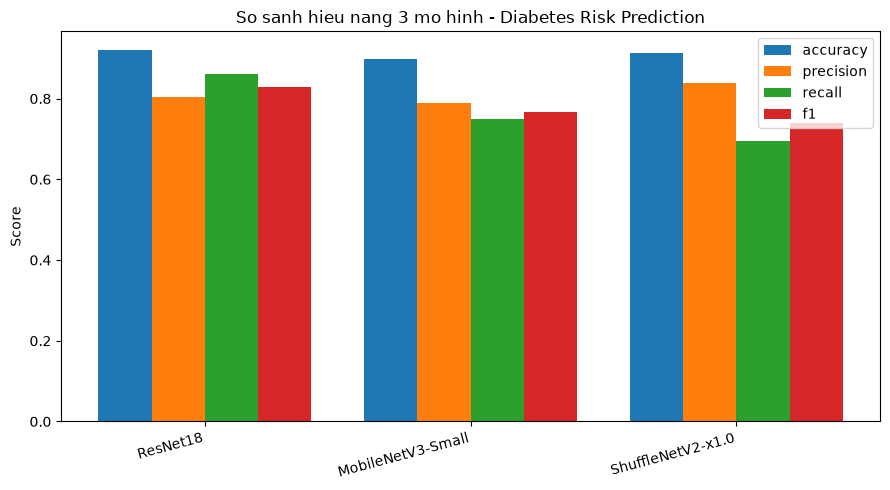

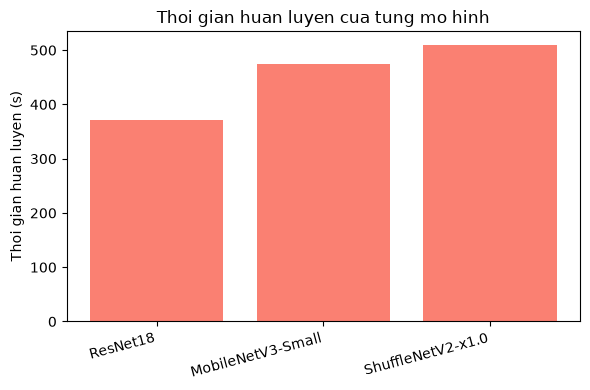

In [11]:
metrics = ["accuracy", "precision", "recall", "f1"]
x = np.arange(len(results_df))
width = 0.2

fig, ax = plt.subplots(figsize=(9, 5))
for i, m in enumerate(metrics):
    ax.bar(x + i * width, results_df[m], width, label=m)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df["name"], rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_title("So sanh hieu nang 3 mo hinh - Diabetes Risk Prediction")
ax.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(results_df["name"], results_df["train_time_s"], color="salmon")
plt.ylabel("Thoi gian huan luyen (s)")
plt.title("Thoi gian huan luyen cua tung mo hinh")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()


ResNet18
              precision    recall  f1-score   support

           0     0.9537    0.9464    0.9501      5489
           1     0.6180    0.7857    0.6918        70
           2     0.8427    0.8527    0.8476      1941

    accuracy                         0.9207      7500
   macro avg     0.8048    0.8616    0.8298      7500
weighted avg     0.9219    0.9207    0.9212      7500



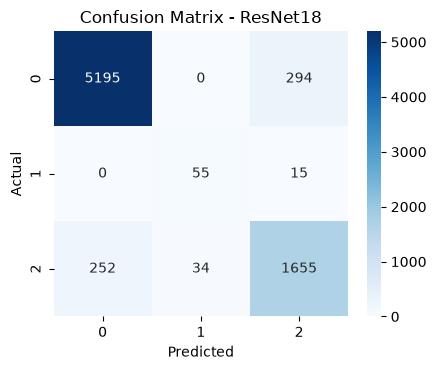


MobileNetV3-Small
              precision    recall  f1-score   support

           0     0.9380    0.9313    0.9346      5489
           1     0.6364    0.5000    0.5600        70
           2     0.7935    0.8156    0.8044      1941

    accuracy                         0.8973      7500
   macro avg     0.7893    0.7490    0.7663      7500
weighted avg     0.8978    0.8973    0.8974      7500



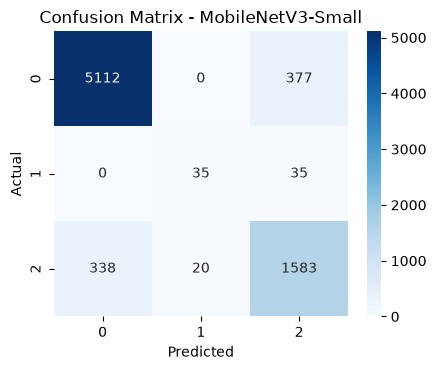


ShuffleNetV2-x1.0
              precision    recall  f1-score   support

           0     0.9368    0.9561    0.9464      5489
           1     0.7333    0.3143    0.4400        70
           2     0.8453    0.8135    0.8291      1941

    accuracy                         0.9132      7500
   macro avg     0.8385    0.6946    0.7385      7500
weighted avg     0.9112    0.9132    0.9113      7500



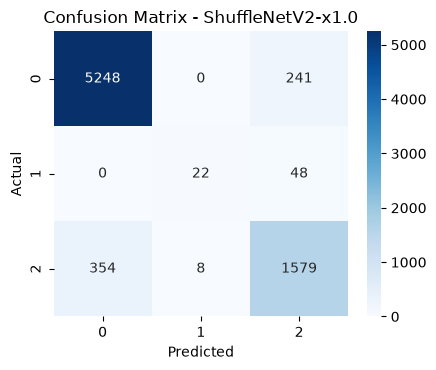

In [12]:
for r in results:
    print(f"\n{'='*60}\n{r['name']}\n{'='*60}")
    print(classification_report(r["truths"], r["preds"], digits=4))
    cm = confusion_matrix(r["truths"], r["preds"])
    plt.figure(figsize=(4.5, 3.8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {r['name']}")
    plt.tight_layout()
    plt.show()

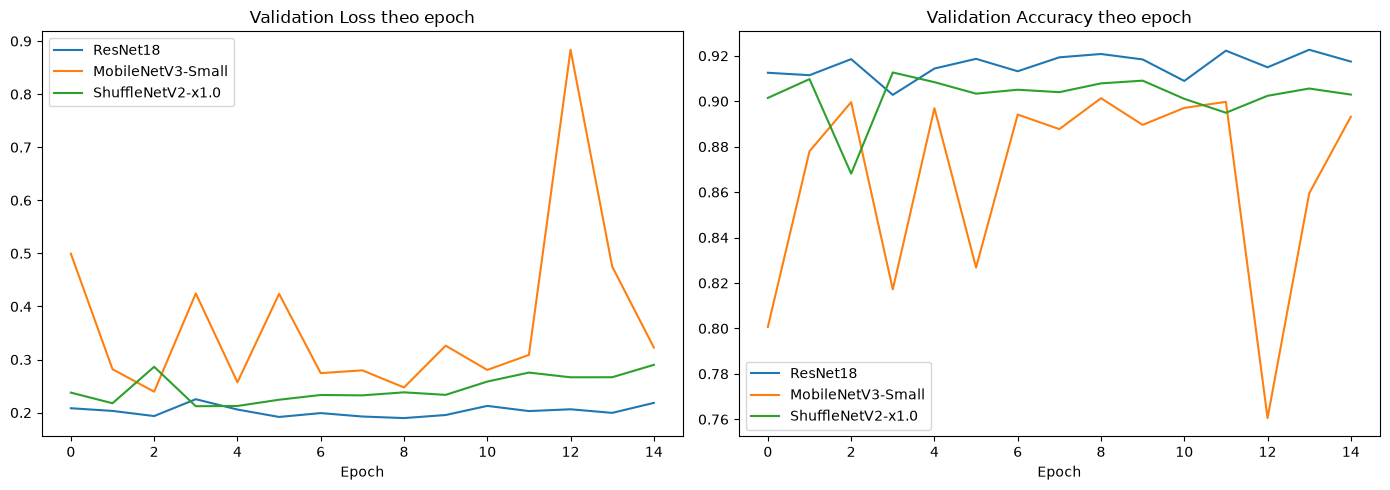

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name in MODEL_REGISTRY:
    h = trained[name]["history"]
    axes[0].plot(h["val_loss"], label=name)
    axes[1].plot(h["val_acc"], label=name)
axes[0].set_title("Validation Loss theo epoch"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Validation Accuracy theo epoch"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout()
plt.show()

## 10. Kết luận

Bảng `results_df` xếp hạng 3 mô hình theo **F1-macro** trên tập test (độc lập với tập train/val).
Mô hình có F1 cao nhất được coi là tốt nhất cho bài toán dự đoán nguy cơ tiểu đường trên dữ liệu bảng này.
Ngoài độ chính xác, nên cân nhắc thêm **thời gian huấn luyện** và **số lượng tham số** (`n_params`) nếu cần triển khai mô hình trong môi trường giới hạn tài nguyên — MobileNetV3-Small và ShuffleNetV2 thường nhẹ hơn đáng kể so với ResNet18.